### Validate that cluster.sort() in the analyzer is also sorting arrays for eta and phi, and not just cluster ID.
* Make plots of eta and phi with colors representing a different cluster
* Get event id, luminosity section, run number to validate to real plots

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import uproot
from datetime import datetime
import plotly.graph_objects as go
import subprocess

In [ ]:
# # Command as a list of arguments
# command = ["./main.sh", "--keep-cmssw", "--keep-clone", "--keep-build"]

# # Run the command
# try:
#     result = subprocess.run(command, check=True, capture_output=True, text=True)
#     print("Command output:")
#     print(result.stdout)
# except subprocess.CalledProcessError as e:
#     print("Command failed with error:")
#     print(e.stderr)


Command output:
=== MDS-ML CMS LLP Analyzer Pipeline ===
Project Directory: /uscms_data/d3/tlee/work/mds-ml
CMSSW Base: /uscms_data/d3/tlee/work/mds-ml/CMSSW_14_1_0_pre4
CMSSW Version: CMSSW_14_1_0_pre4
Target Branch: add-rechit-data
Analyzer: llp_MuonSystem_CA_mdsnano

Pipeline mode:
  Keep CMSSW: true
  Keep Clone: true
  Keep Build: true
  Skip Branch: false
  Run Analyzer: true

=== Stage 1: Setting up Environment ===
Setting up CMSSW environment...
✓ CMSSW environment sourced
⚠️  ROOT setup path not found or not specified: 
   Will use default ROOT from CMSSW

Environment Check:
  CMSSW_BASE: /uscms_data/d3/tlee/work/mds-ml/CMSSW_14_1_0_pre4
  ROOT Version: Not available
  Architecture: el9_amd64_gcc12

=== Stage 2: Using existing CMSSW release ===
Using existing CMSSW release: CMSSW_14_1_0_pre4
✓ CMSSW environment activated

CMSSW Setup Complete:
  CMSSW_BASE: /uscms_data/d3/tlee/work/mds-ml/CMSSW_14_1_0_pre4
  CMSSW_VERSION: CMSSW_14_1_0_pre4
  SCRAM_ARCH: el9_amd64_gcc12
  Work

In [25]:
DATA_FILE = '/uscms/home/tlee/nobackup/work/mds-ml/data/MuonSystem_Tree.root'
OUTPUT_DIR = '/uscms/home/tlee/nobackup/work/mds-ml/notebooks/validate_cluster_sort/images'
TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

root_file = uproot.open(DATA_FILE)
tree = root_file['MuonSystem']

event_num = tree['evtNum'].array(library='np')
lumi_section = tree['lumiSec'].array(library='np')
run_num = tree['runNum'].array(library='np')

csc_phi = tree['CscRechitsPhi'].array(library='np')
csc_eta = tree['CscRechitsEta'].array(library='np')
csc_id = tree['CscRechitsClusterId'].array(library='np')

csc_cluster_phi = tree['cscRechitClusterPhi'].array(library='np')
csc_cluster_eta = tree['cscRechitClusterEta'].array(library='np')

dt_phi = tree['DtRechitsPhi'].array(library='np')
dt_eta = tree['DtRechitsEta'].array(library='np')
dt_id = tree['DtRechitsClusterId'].array(library='np')

dt_cluster_phi = tree['dtRechitClusterPhi'].array(library='np')
dt_cluster_eta = tree['dtRechitClusterEta'].array(library='np')

print("CSC Phi: ")
print(csc_phi.shape)
print("CSC Eta: ")
print(csc_eta.shape)
print("CSC Id: ")
print(csc_id.shape)

print("CSC Cluster Phi: ")
print(csc_cluster_phi.shape)
print("CSC Cluster Eta: ")
print(csc_cluster_eta.shape)

print("DT Phi: ")
print(dt_phi.shape)
print("DT Eta: ")
print(dt_eta.shape  )
print("DT Id: ")
print(dt_id.shape)

print("DT Cluster Phi: ")
print(dt_cluster_phi.shape)
print("DT Cluster Eta: ")
print(dt_cluster_eta.shape)

CSC Phi: 
(2,)
CSC Eta: 
(2,)
CSC Id: 
(2,)
CSC Cluster Phi: 
(2,)
CSC Cluster Eta: 
(2,)
DT Phi: 
(2,)
DT Eta: 
(2,)
DT Id: 
(2,)
DT Cluster Phi: 
(2,)
DT Cluster Eta: 
(2,)


In [ ]:
print(f"event_num: {event_num}")
print(f"run_num: {run_num}") 
print(f"lumi_section: {lumi_section}")

event_num: [67859 67928]
run_num: [1 1]
lumi_section: [679 680]


In [27]:

# Define function to convert eta/phi to 3D Cartesian coordinates
def eta_phi_to_xyz(eta, phi):
    theta = 2 * np.arctan(np.exp(-eta))  # polar angle
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y, z

def safe_concatenate(arr_list):
    return np.concatenate([np.atleast_1d(arr) for arr in arr_list if arr.size > 0])

# Flatten and convert
csc_phi = safe_concatenate(csc_phi)
csc_eta = safe_concatenate(csc_eta)
csc_id = safe_concatenate(csc_id)

dt_phi = safe_concatenate(dt_phi)
dt_eta = safe_concatenate(dt_eta)
dt_id = safe_concatenate(dt_id)

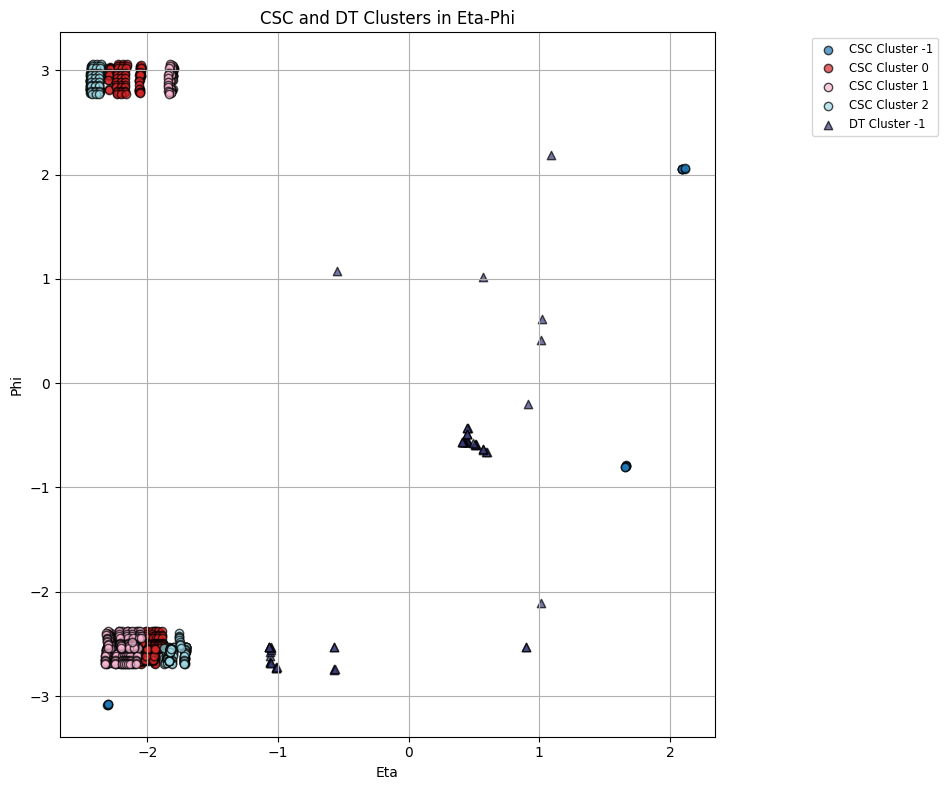

In [28]:
# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# CSC cluster plot
unique_csc_ids = np.unique(csc_id)
cmap_csc = mpl.colormaps.get_cmap('tab20')
colors_csc = cmap_csc(np.linspace(0, 1, len(unique_csc_ids)))

for i, cid in enumerate(unique_csc_ids):
    mask = csc_id == cid
    ax.scatter(
        csc_eta[mask], csc_phi[mask],
        label=f'CSC Cluster {cid}',
        c=[colors_csc[i]],
        marker='o',
        edgecolors='k',
        alpha=0.7
    )

# DT cluster plot
unique_dt_ids = np.unique(dt_id)
cmap_dt = mpl.colormaps.get_cmap('tab20b')
colors_dt = cmap_dt(np.linspace(0, 1, len(unique_dt_ids)))

for i, did in enumerate(unique_dt_ids):
    mask = dt_id == did
    ax.scatter(
        dt_eta[mask], dt_phi[mask],
        label=f'DT Cluster {did}',
        c=[colors_dt[i]],
        marker='^',
        edgecolors='k',
        alpha=0.7
    )

ax.set_xlabel('Eta')
ax.set_ylabel('Phi')
ax.set_title('CSC and DT Clusters in Eta-Phi')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0), fontsize='small')
plt.grid(True)
plt.tight_layout()

# Save with timestamp
plt.savefig(f'{OUTPUT_DIR}/{TIMESTAMP}_csc_dt_clusters.png')
plt.show()

In [29]:
# ----------- Individual CSC Plots -----------
for i, cid in enumerate(unique_csc_ids):
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = csc_id == cid
    ax.scatter(
        csc_eta[mask], csc_phi[mask],
        c=[colors_csc[i]],
        marker='o',
        edgecolors='k',
        alpha=0.7
    )
    ax.set_xlabel('Eta')
    ax.set_ylabel('Phi')
    ax.set_title(f'CSC Cluster {cid}')
    plt.grid(True)
    plt.tight_layout()
    file_path = f'{OUTPUT_DIR}/{TIMESTAMP}_csc_cluster_{cid}.png'
    plt.savefig(file_path)
    plt.close()

# ----------- Individual DT Plots -----------
for i, did in enumerate(unique_dt_ids):
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = dt_id == did
    ax.scatter(
        dt_eta[mask], dt_phi[mask],
        c=[colors_dt[i]],
        marker='^',
        edgecolors='k',
        alpha=0.7
    )
    ax.set_xlabel('Eta')
    ax.set_ylabel('Phi')
    ax.set_title(f'DT Cluster {did}')
    plt.grid(True)
    plt.tight_layout()
    file_path = f'{OUTPUT_DIR}/{TIMESTAMP}_dt_cluster_{did}.png'
    plt.savefig(file_path)
    plt.close()

In [30]:
csc_x, csc_y, csc_z = eta_phi_to_xyz(csc_eta, csc_phi)
dt_x, dt_y, dt_z = eta_phi_to_xyz(dt_eta, dt_phi)

# Create a list of Plotly traces
fig = go.Figure()

# CSC Clusters
unique_csc_ids = np.unique(csc_id)
for cid in unique_csc_ids:
    mask = csc_id == cid
    fig.add_trace(go.Scatter3d(
        x=csc_x[mask], y=csc_y[mask], z=csc_z[mask],
        mode='markers',
        marker=dict(size=4, symbol='circle', line=dict(width=1, color='black')),
        name=f'CSC Cluster {int(cid)}'
    ))

# DT Clusters
unique_dt_ids = np.unique(dt_id)
for did in unique_dt_ids:
    mask = dt_id == did
    fig.add_trace(go.Scatter3d(
        x=dt_x[mask], y=dt_y[mask], z=dt_z[mask],
        mode='markers',
        marker=dict(size=4, symbol='diamond', line=dict(width=1, color='black')),
        name=f'DT Cluster {int(did)}'
    ))

# Layout with sphere feel
fig.update_layout(
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data',
    ),
    title='CSC and DT Clusters on a Unit Sphere',
    margin=dict(l=0, r=0, b=0, t=40),
    showlegend=True
)

fig.show()
